<a href="https://colab.research.google.com/github/IAMIOT1/h-c-m-y-/blob/main/Tuan3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# 1. Kết nối Google Drive
drive.mount('/content/drive')

# 2. Đọc tệp CSV từ đường dẫn trên Drive
file_path = '/content/drive/My Drive/học máy/DL1.csv'
df = pd.read_csv(file_path)

# Xử lý chuỗi số Income (loại bỏ dấu phẩy nếu có)
df['Income ($)'] = df['Income ($)'].astype(str).str.replace(',', '').str.strip().astype(float)
df['Purchased'] = df['Purchased'].str.strip()

# 3. Tách thuộc tính đầu vào (X) và nhãn (y)
X_train = df[['Age', 'Income ($)']].values
y_train = df['Purchased'].values

# Dữ liệu cần dự đoán
X_new = np.array([[32, 58000]])

# 4. Chuẩn hóa dữ liệu (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_new_scaled = scaler.transform(X_new)

# 5. Huấn luyện mô hình KNN (K = 3)
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn.fit(X_train_scaled, y_train)

# 6. Dự đoán
prediction = knn.predict(X_new_scaled)
probability = knn.predict_proba(X_new_scaled)

print(f"-> Dự đoán cho Age=32, Income=58000: Purchased = '{prediction[0]}'")
print(f"-> Tỷ lệ dự đoán (Các lớp {knn.classes_}): {probability[0]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
-> Dự đoán cho Age=32, Income=58000: Purchased = 'No'
-> Tỷ lệ dự đoán (Các lớp ['No' 'Yes']): [0.66666667 0.33333333]


bài 2

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1. Kích thước dữ liệu gốc: (228, 14)
Đã xóa các cột: ['Product_ID', 'Created_Date', 'Description']


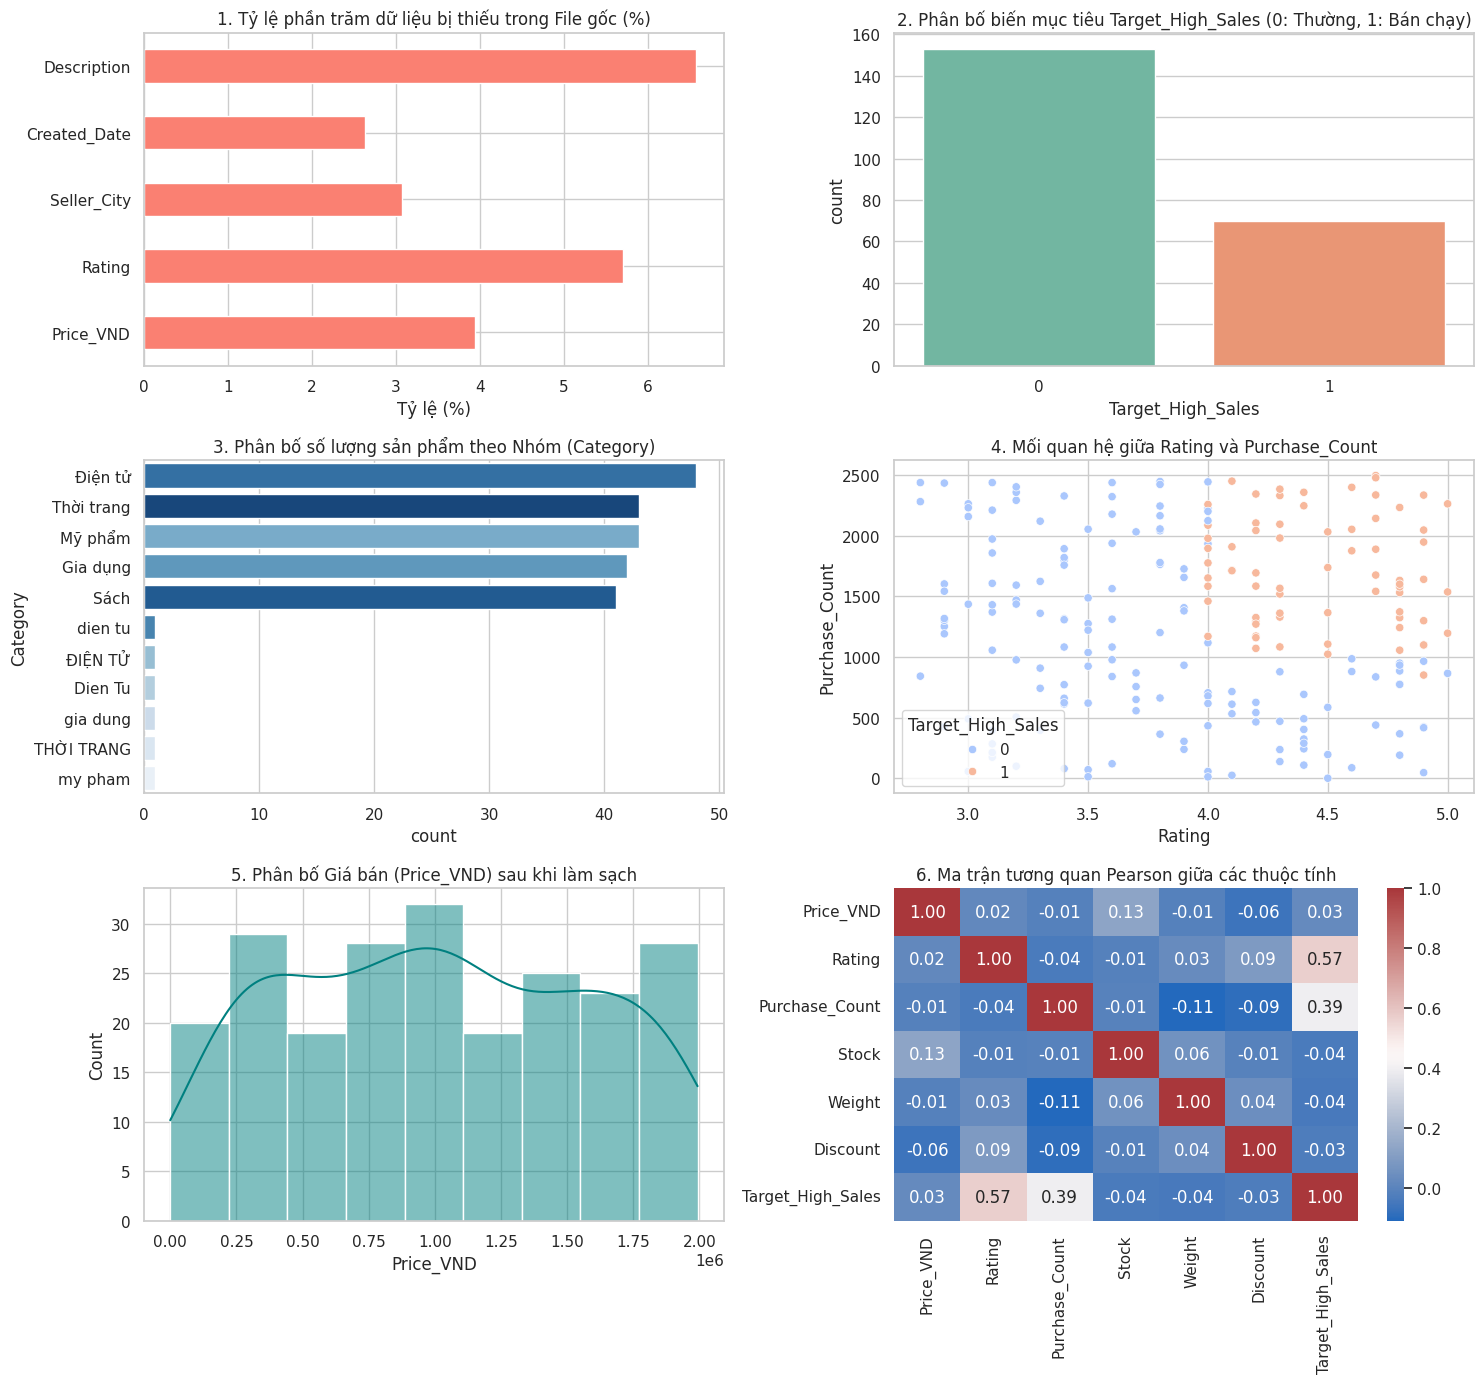

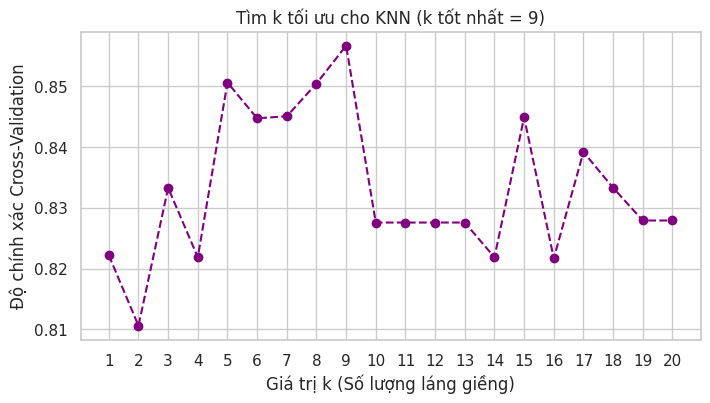

ĐỘ CHÍNH XÁC CỦA MÔ HÌNH (ACCURACY): 0.8636

KẾT QUẢ BÁO CÁO (CLASSIFICATION REPORT):
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        30
           1       0.79      0.79      0.79        14

    accuracy                           0.86        44
   macro avg       0.84      0.84      0.84        44
weighted avg       0.86      0.86      0.86        44



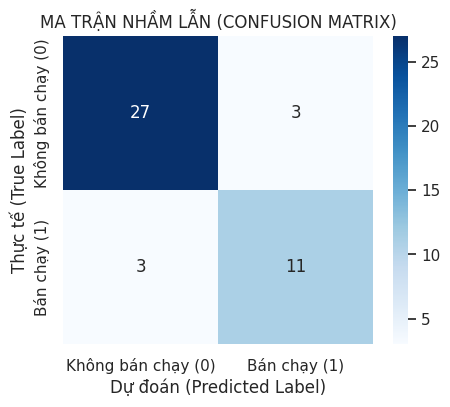

KẾT QUẢ DỰ ĐOÁN CHO 5 DÒNG CUỐI CÙNG:
       Product_Name  Price_VND  Rating  Purchase_Count  Stock  Weight  Discount  Target_High_Sales  Predicted_Target_High_Sales
     Ấm siêu tốc E4  1334000.0     2.9          2432.0   23.0   153.0      0.20                  0                            0
        Loa mini A1   728000.0     3.2           975.0  270.0   226.0      0.20                  0                            0
Bản sao mã sản phẩm  1103000.0     4.9          1098.0  189.0  1003.0      0.20                  1                            1
   Cơ sở dữ liệu B2  1234000.0     3.5          1036.0  228.0  1561.0      0.15                  0                            0
    Sạc dự phòng B4  1683000.0     3.5           619.0  169.0   506.0      0.25                  0                            0


In [10]:
# ==============================================================================
# BƯỚC 1: CÀI ĐẶT & THƯ VIỆN CẦN THIẾT
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# 1. Kết nối Google Drive
drive.mount('/content/drive')

# Cấu hình hiển thị biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================================
# BƯỚC 2: ĐỌC VÀ LÀM SẠCH DỮ LIỆU TỪ FILE EXCEL
# ==============================================================================
file_path = '/content/drive/MyDrive/học máy/Du_lieu_thuc_hanh_chuan_bi_du_lieu.xlsx'
df_raw = pd.read_excel(file_path, sheet_name='Du_lieu_tho')

print("1. Kích thước dữ liệu gốc:", df_raw.shape)

# Tạo bản sao để làm sạch
df = df_raw.copy()

# 2.0 XÓA 3 CỘT: ID, MÔ TẢ, NGÀY THÁNG
keywords_to_remove = ['id', 'mô tả', 'mo_ta', 'mota', 'description', 'ngày', 'ngay', 'date']
cols_to_drop = [col for col in df.columns if any(kw in col.lower() for kw in keywords_to_remove)]
df = df.drop(columns=cols_to_drop, errors='ignore')
print(f"Đã xóa các cột: {cols_to_drop}")

# 2.1 Bỏ các dòng trùng lặp hoàn toàn
df = df.drop_duplicates()

# 2.2 Chuẩn hóa Price_VND
def clean_price(val):
    if pd.isna(val): return np.nan
    val_str = str(val).replace(',', '').replace('.', '').replace('đ', '').replace('VND', '').strip()
    if val_str.lower() == 'miễn phí': return 0.0
    try:
        p = float(val_str)
        return p if p >= 0 else np.nan
    except:
        return np.nan

df['Price_VND'] = df['Price_VND'].apply(clean_price)

# 2.3 Chuẩn hóa Rating (từ 1 đến 5)
def clean_rating(val):
    if pd.isna(val) or str(val).strip().upper() == 'N/A': return np.nan
    val_str = str(val).replace('sao', '').strip()
    try:
        r = float(val_str)
        return r if 1.0 <= r <= 5.0 else np.nan
    except:
        return np.nan

df['Rating'] = df['Rating'].apply(clean_rating)

# 2.4 Chuẩn hóa Purchase_Count
def clean_purchase(val):
    if pd.isna(val): return np.nan
    val_str = str(val).replace(',', '').replace('lượt', '').strip().lower()
    if 'k' in val_str:
        try: return float(val_str.replace('k', '')) * 1000
        except: return np.nan
    try:
        p = float(val_str)
        return p if p >= 0 else np.nan
    except:
        return np.nan

df['Purchase_Count'] = df['Purchase_Count'].apply(clean_purchase)

# 2.5 Chuẩn hóa Stock (Số lượng tồn >= 0)
df['Stock'] = pd.to_numeric(df['Stock'], errors='coerce')
df['Stock'] = df['Stock'].apply(lambda x: x if (pd.notna(x) and x >= 0 and x < 5000) else np.nan)

# 2.6 Chuẩn hóa Weight (đơn vị gram)
def clean_weight(val):
    if pd.isna(val): return np.nan
    val_str = str(val).lower().replace('nặng', '').strip()
    if 'kg' in val_str:
        try: return float(val_str.replace('kg', '').strip()) * 1000
        except: return np.nan
    elif 'g' in val_str:
        try: return float(val_str.replace('g', '').strip())
        except: return np.nan
    try:
        w = float(val_str)
        return w if w > 0 else np.nan
    except:
        return np.nan

df['Weight'] = df['Weight'].apply(clean_weight)

# 2.7 Chuẩn hóa Discount (từ 0 đến 1)
def clean_discount(val):
    if pd.isna(val): return np.nan
    val_str = str(val).replace('%', '').replace('phần trăm', '').strip()
    try:
        d = float(val_str)
        if d > 1.0: d /= 100.0
        return d if 0.0 <= d <= 1.0 else np.nan
    except:
        return np.nan

df['Discount'] = df['Discount'].apply(clean_discount)

# Điền giá trị thiếu (Imputation) bằng Median cho các thuộc tính số
num_cols = ['Price_VND', 'Rating', 'Purchase_Count', 'Stock', 'Weight', 'Discount']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# ==============================================================================
# BƯỚC 3: TRỰC QUAN HÓA TẤT CẢ CÁC VẤN ĐỀ VÀ ĐẶC TRƯNG TRONG FILE
# ==============================================================================
fig, axes = plt.subplots(3, 2, figsize=(15, 14))

# Biểu đồ 1: Tỷ lệ thiếu dữ liệu trong file gốc
missing_pct = df_raw.isna().sum() / len(df_raw) * 100
missing_pct[missing_pct > 0].plot(kind='barh', ax=axes[0, 0], color='salmon')
axes[0, 0].set_title('1. Tỷ lệ phần trăm dữ liệu bị thiếu trong File gốc (%)')
axes[0, 0].set_xlabel('Tỷ lệ (%)')

# Biểu đồ 2: Phân bố biến mục tiêu (Target_High_Sales)
sns.countplot(data=df, x='Target_High_Sales', hue='Target_High_Sales', ax=axes[0, 1], palette='Set2', legend=False)
axes[0, 1].set_title('2. Phân bố biến mục tiêu Target_High_Sales (0: Thường, 1: Bán chạy)')

# Biểu đồ 3: Phân bố nhóm sản phẩm (Category) - Kiểm tra xem cột có tồn tại không
if 'Category' in df.columns:
    sns.countplot(data=df, y='Category', hue='Category', ax=axes[1, 0], order=df['Category'].value_counts().index, palette='Blues_r', legend=False)
    axes[1, 0].set_title('3. Phân bố số lượng sản phẩm theo Nhóm (Category)')
else:
    axes[1, 0].text(0.5, 0.5, 'Không có cột Category', ha='center', va='center')

# Biểu đồ 4: Điểm đánh giá (Rating) vs Lượt mua (Purchase_Count)
sns.scatterplot(data=df, x='Rating', y='Purchase_Count', hue='Target_High_Sales', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('4. Mối quan hệ giữa Rating và Purchase_Count')

# Biểu đồ 5: Phân bố Giá bán (Price_VND)
sns.histplot(df['Price_VND'], kde=True, ax=axes[2, 0], color='teal')
axes[2, 0].set_title('5. Phân bố Giá bán (Price_VND) sau khi làm sạch')

# Biểu đồ 6: Ma trận tương quan giữa các biến số
sns.heatmap(df[num_cols + ['Target_High_Sales']].corr(), annot=True, fmt='.2f', cmap='vlag', ax=axes[2, 1])
axes[2, 1].set_title('6. Ma trận tương quan Pearson giữa các thuộc tính')

plt.tight_layout()
plt.show()

# ==============================================================================
# BƯỚC 4: HUẤN LUYỆN MÔ HÌNH VÀ DỰ ĐOÁN
# ==============================================================================

# YÊU CẦU 1: Cắt 5 dòng cuối cùng để dành riêng cho dự đoán
df_model = df.iloc[:-5].copy()
df_predict = df.iloc[-5:].copy()

X = df_model[num_cols]
y = df_model['Target_High_Sales']

X_holdout = df_predict[num_cols]

# YÊU CẦU 2: Chia dữ liệu Train/Test (Tỷ lệ 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Chuẩn hóa đặc trưng (Scaling) cho KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_holdout_scaled = scaler.transform(X_holdout)

# YÊU CẦU 3: Tìm k tối ưu bằng Cross-Validation
k_range = range(1, 21)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

optimal_k = k_range[np.argmax(k_scores)]

# Trực quan hóa quá trình tìm k tối ưu
plt.figure(figsize=(8, 4))
plt.plot(k_range, k_scores, marker='o', linestyle='--', color='purple')
plt.title(f'Tìm k tối ưu cho KNN (k tốt nhất = {optimal_k})')
plt.xlabel('Giá trị k (Số lượng láng giềng)')
plt.ylabel('Độ chính xác Cross-Validation')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# YÊU CẦU 4: Huấn luyện mô hình KNN với k tối ưu
best_knn = KNeighborsClassifier(n_neighbors=optimal_k)
best_knn.fit(X_train_scaled, y_train)

# YÊU CẦU 5: Đánh giá mô hình - Accuracy, Confusion Matrix, Classification Report
y_pred = best_knn.predict(X_test_scaled)

print("="*60)
print(f"ĐỘ CHÍNH XÁC CỦA MÔ HÌNH (ACCURACY): {accuracy_score(y_test, y_pred):.4f}")
print("="*60)

print("\nKẾT QUẢ BÁO CÁO (CLASSIFICATION REPORT):")
print(classification_report(y_test, y_pred))

# Vẽ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Không bán chạy (0)', 'Bán chạy (1)'],
            yticklabels=['Không bán chạy (0)', 'Bán chạy (1)'])
plt.title('MA TRẬN NHẦM LẪN (CONFUSION MATRIX)')
plt.xlabel('Dự đoán (Predicted Label)')
plt.ylabel('Thực tế (True Label)')
plt.show()

# ==============================================================================
# BƯỚC 5: DÙNG MÔ HÌNH ĐỂ DỰ ĐOÁN 5 DÒNG CUỐI CÙNG ĐÃ CẮT
# ==============================================================================
predictions = best_knn.predict(X_holdout_scaled)
df_predict['Predicted_Target_High_Sales'] = predictions

print("="*60)
print("KẾT QUẢ DỰ ĐOÁN CHO 5 DÒNG CUỐI CÙNG:")
print("="*60)

available_cols = [c for c in ['Product_Name', 'Ten_San_Pham'] if c in df_predict.columns]
display_cols = available_cols + num_cols + ['Target_High_Sales', 'Predicted_Target_High_Sales']

print(df_predict[display_cols].to_string(index=False))